# A Simple, Reproducible xG Model

This notebook builds expected-goals models from EPL shot events. It compares a constant goal-rate baseline, a distance-and-angle logistic regression, and a contextual logistic regression against Understat's published xG. All evaluation is chronological: 2014–2022 is used for training and 2023 is held out, with additional rolling-season checks.

In [1]:
from pathlib import Path

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import brier_score_loss, log_loss, roc_auc_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [2]:
LEAGUE = "EPL"
EXCLUDE_PENALTIES = True
TRAIN_UP_TO_SEASON = None
FIGURE_DIR = Path("figures")
FIGURE_DIR.mkdir(exist_ok=True)

PITCH_LENGTH_METERS = 105.0
PITCH_WIDTH_METERS = 68.0
GOAL_WIDTH_METERS = 7.32

In [3]:
def _normalize_shot_coordinate(series):
    values = pd.to_numeric(series, errors="coerce")
    return values.where(values <= 1, values / 1000)


def _detect_csv_separator(file_path: Path) -> str:
    with file_path.open("r", encoding="utf-8", errors="replace") as file_handle:
        header = file_handle.readline()

    if header.count(";") > header.count(","):
        return ";"

    return ","


def load_shot_data(league: str) -> pd.DataFrame:
    dataset_path = Path(kagglehub.dataset_download("mexwell/understat-database")) / "understats"
    file_path = dataset_path / league / "shot_data.csv"
    dataframe = pd.read_csv(file_path, sep=_detect_csv_separator(file_path))

    unnamed_columns = [
        column
        for column in dataframe.columns
        if str(column).startswith("Unnamed") or str(column).strip() == ""
    ]
    if unnamed_columns:
        dataframe = dataframe.drop(columns=unnamed_columns)

    for axis in ["X", "Y"]:
        if axis not in dataframe.columns:
            raise KeyError(f"Missing required coordinate column: {axis}")
        dataframe[axis] = _normalize_shot_coordinate(dataframe[axis])

    return dataframe


shot_data = load_shot_data(LEAGUE)
shot_data.head()

,id,minute,result,X,Y,xG,player,h_a,player_id,situation,season,shotType,match_id,h_team,a_team,h_goals,a_goals,date,player_assisted,lastAction
0,14511,12,SavedShot,0.728,0.501,0.018741,Wayne Rooney,h,629,OpenPlay,2014,RightFoot,4749,Manchester United,Swansea,1,2,2014-08-16 12:45:00,Darren Fletcher,Pass
1,14512,16,BlockedShot,0.789,0.336,0.015598,Wayne Rooney,h,629,OpenPlay,2014,RightFoot,4749,Manchester United,Swansea,1,2,2014-08-16 12:45:00,Chicharito,TakeOn
2,14513,25,SavedShot,0.914,0.188,0.064923,Juan Mata,h,554,DirectFreekick,2014,LeftFoot,4749,Manchester United,Swansea,1,2,2014-08-16 12:45:00,NaN,Standard
3,14514,26,SavedShot,0.920,0.482,0.057788,Wayne Rooney,h,629,OpenPlay,2014,Head,4749,Manchester United,Swansea,1,2,2014-08-16 12:45:00,Ashley Young,Aerial
4,14516,33,MissedShots,0.922,0.590,0.048801,Wayne Rooney,h,629,FromCorner,2014,Head,4749,Manchester United,Swansea,1,2,2014-08-16 12:45:00,Juan Mata,Cross


In [4]:
schema_summary = pd.DataFrame({
    "dtype": shot_data.dtypes.astype(str),
    "missing_values": shot_data.isna().sum(),
}).sort_index()

display(schema_summary)
display(shot_data[["result", "situation", "shotType", "season"]].describe(include="all"))

,dtype,missing_values
X,float64,0
Y,float64,0
a_goals,int64,0
a_team,str,0
date,str,0
h_a,str,0
h_goals,int64,0
h_team,str,0
id,int64,0
lastAction,str,11402


,result,situation,shotType,season
count,97046,97046,97046,97046.000000
unique,6,5,4,NaN
top,MissedShots,OpenPlay,RightFoot,NaN
freq,35074,70896,50164,NaN
mean,NaN,NaN,NaN,2018.520351
std,NaN,NaN,NaN,2.908237
min,NaN,NaN,NaN,2014.000000
25%,NaN,NaN,NaN,2016.000000
50%,NaN,NaN,NaN,2019.000000
75%,NaN,NaN,NaN,2021.000000


# Spatial Features

In [5]:
def compute_shot_features(shots: pd.DataFrame, exclude_penalties: bool = True) -> pd.DataFrame:
    """Create spatial and event-context features without using Understat's xG value."""
    required = ["X", "Y", "result", "season", "shotType", "situation", "h_a", "minute"]
    modeled = shots.dropna(subset=required).copy()

    if not modeled[["X", "Y"]].apply(lambda column: column.between(0, 1).all()).all():
        raise ValueError("Shot coordinates must be normalized to the [0, 1] interval.")

    modeled = modeled[modeled["result"] != "OwnGoal"].copy()
    if exclude_penalties:
        modeled = modeled[modeled["situation"] != "Penalty"].copy()

    modeled["lastAction"] = modeled["lastAction"].fillna("Unknown")
    modeled["is_goal"] = (modeled["result"] == "Goal").astype(int)

    distance_x = (1 - modeled["X"]) * PITCH_LENGTH_METERS
    central_offset = (modeled["Y"] - 0.5).abs() * PITCH_WIDTH_METERS
    modeled["distance_meters"] = np.hypot(distance_x, central_offset)

    numerator = GOAL_WIDTH_METERS * distance_x
    denominator = distance_x.pow(2) + central_offset.pow(2) - (GOAL_WIDTH_METERS / 2) ** 2
    modeled["angle_radians"] = np.arctan2(numerator, denominator).where(
        lambda angle: angle >= 0, lambda angle: angle + np.pi
    )

    # These describe the recorded action immediately before the shot; they do not
    # directly measure defender pressure or the shooter's decision-making.
    for action in ["Cross", "TakeOn", "Aerial", "Throughball", "Rebound"]:
        modeled[f"follows_{action.lower()}"] = (modeled["lastAction"] == action).astype(int)

    return modeled


model_data = compute_shot_features(shot_data, exclude_penalties=EXCLUDE_PENALTIES)
model_data[[
    "result", "is_goal", "distance_meters", "angle_radians",
    "shotType", "situation", "lastAction", "season",
]].head()

,result,is_goal,distance_meters,angle_radians,shotType,situation,lastAction,season
0,SavedShot,0,28.560078,0.254912,RightFoot,OpenPlay,Pass,2014
1,BlockedShot,0,24.803449,0.263223,RightFoot,OpenPlay,TakeOn,2014
2,SavedShot,0,23.057744,0.126856,LeftFoot,DirectFreekick,Standard,2014
3,SavedShot,0,8.488709,0.808910,Head,OpenPlay,Aerial,2014
4,MissedShots,0,10.224018,0.581856,Head,FromCorner,Cross,2014


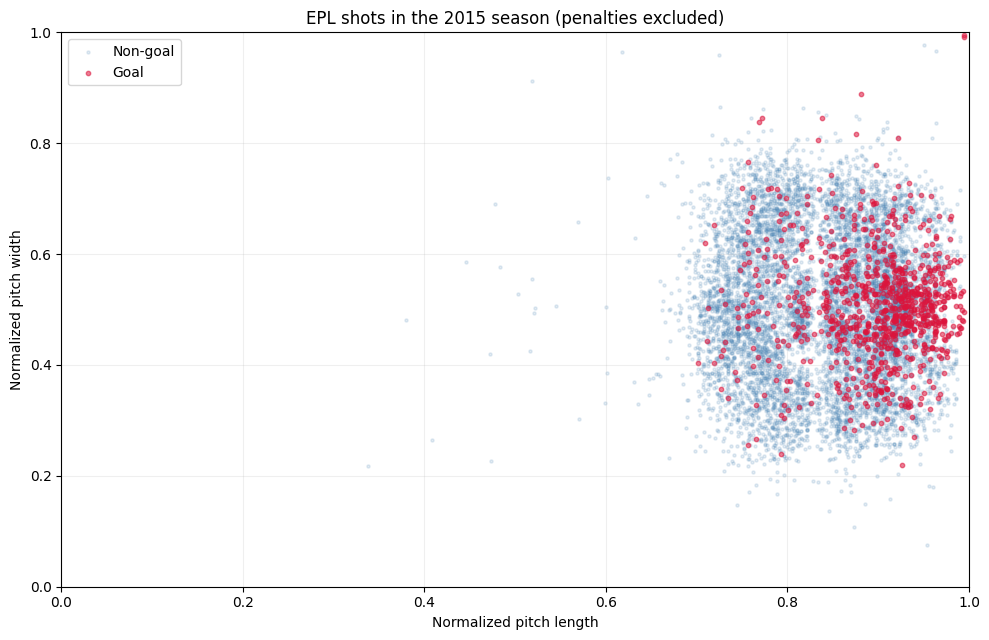

In [6]:
# A simple shot map establishes how Understat's normalized coordinates map to the pitch.
shots_2015 = model_data[model_data["season"] == 2015]
fig, ax = plt.subplots(figsize=(10, 6.5))
non_goals = shots_2015[shots_2015["is_goal"] == 0]
goals = shots_2015[shots_2015["is_goal"] == 1]
ax.scatter(non_goals["X"], non_goals["Y"], s=5, alpha=0.15, color="steelblue", label="Non-goal")
ax.scatter(goals["X"], goals["Y"], s=10, alpha=0.55, color="crimson", label="Goal")
ax.set(xlim=(0, 1), ylim=(0, 1), xlabel="Normalized pitch length", ylabel="Normalized pitch width")
ax.set_title("EPL shots in the 2015 season (penalties excluded)")
ax.legend()
ax.grid(alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "epl_shot_map_goals_2015.png", dpi=180, bbox_inches="tight")
plt.show()

In [7]:
season_values = sorted(model_data["season"].unique())
if len(season_values) < 2:
    raise ValueError("At least two seasons are required for a chronological split.")

validation_season = season_values[-1]
train_season_cutoff = season_values[-2] if TRAIN_UP_TO_SEASON is None else TRAIN_UP_TO_SEASON
if train_season_cutoff >= validation_season:
    raise ValueError("TRAIN_UP_TO_SEASON must precede the validation season.")

train_mask = model_data["season"] <= train_season_cutoff
validation_mask = model_data["season"] == validation_season
if not train_mask.any() or not validation_mask.any():
    raise ValueError("The chronological train/validation split is empty.")

spatial_features = ["distance_meters", "angle_radians"]
context_numeric_features = [
    "minute", "follows_cross", "follows_takeon", "follows_aerial",
    "follows_throughball", "follows_rebound",
]
context_categorical_features = ["shotType", "situation", "h_a", "lastAction"]
context_features = spatial_features + context_numeric_features + context_categorical_features
target_column = "is_goal"

train_data = model_data.loc[train_mask].copy()
validation_data = model_data.loc[validation_mask].copy()

split_summary = pd.DataFrame([
    {
        "split": "train", "rows": len(train_data),
        "goal_rate": train_data[target_column].mean(),
        "seasons": f"{train_data['season'].min()}–{train_data['season'].max()}",
    },
    {
        "split": "validation", "rows": len(validation_data),
        "goal_rate": validation_data[target_column].mean(),
        "seasons": str(validation_season),
    },
])
display(split_summary)

,split,rows,goal_rate,seasons
0,train,85321,0.097971,2014–2022
1,validation,10367,0.106106,2023


In [8]:
def make_logistic_model(numeric_features, categorical_features=None):
    transformers = [("numeric", StandardScaler(), numeric_features)]
    if categorical_features:
        transformers.append((
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ))
    return Pipeline([
        ("preprocessor", ColumnTransformer(transformers=transformers)),
        ("classifier", LogisticRegression(max_iter=2000, solver="lbfgs")),
    ])


def score_probabilities(name, y_true, probabilities):
    return {
        "model": name,
        "log_loss": log_loss(y_true, probabilities),
        "brier_score": brier_score_loss(y_true, probabilities),
        "roc_auc": roc_auc_score(y_true, probabilities),
        "mean_prediction": np.mean(probabilities),
    }


y_train = train_data[target_column]
y_validation = validation_data[target_column]

constant_predictions = np.full(len(validation_data), y_train.mean())
spatial_model = make_logistic_model(spatial_features)
spatial_model.fit(train_data[spatial_features], y_train)
spatial_predictions = spatial_model.predict_proba(validation_data[spatial_features])[:, 1]

context_model = make_logistic_model(
    spatial_features + context_numeric_features,
    context_categorical_features,
)
context_model.fit(train_data[context_features], y_train)
validation_predictions = context_model.predict_proba(validation_data[context_features])[:, 1]
understat_predictions = validation_data["xG"].astype(float).to_numpy()

metrics = pd.DataFrame([
    score_probabilities("Constant goal-rate baseline", y_validation, constant_predictions),
    score_probabilities("Distance + angle", y_validation, spatial_predictions),
    score_probabilities("Contextual logistic regression", y_validation, validation_predictions),
    score_probabilities("Understat xG", y_validation, understat_predictions),
]).set_index("model")
display(metrics.round(4))

rolling_rows = []
for held_out_season in season_values[3:]:
    fold_train = model_data[model_data["season"] < held_out_season]
    fold_validation = model_data[model_data["season"] == held_out_season]
    fold_model = make_logistic_model(
        spatial_features + context_numeric_features,
        context_categorical_features,
    )
    fold_model.fit(fold_train[context_features], fold_train[target_column])
    fold_predictions = fold_model.predict_proba(fold_validation[context_features])[:, 1]
    rolling_rows.append({
        "season": held_out_season,
        **score_probabilities("contextual", fold_validation[target_column], fold_predictions),
    })

rolling_metrics = pd.DataFrame(rolling_rows).drop(columns="model").set_index("season")
display(rolling_metrics.round(4))

,log_loss,brier_score,roc_auc,mean_prediction
model,,,,
Constant goal-rate baseline,0.3387,0.0949,0.5000,0.0980
Distance + angle,0.3017,0.0860,0.7331,0.1061
Contextual logistic regression,0.2886,0.0826,0.7713,0.1087
Understat xG,0.2722,0.0775,0.7952,0.1182


,log_loss,brier_score,roc_auc,mean_prediction
season,,,,
2017,0.2707,0.0775,0.7977,0.0996
2018,0.2738,0.0777,0.7798,0.1008
2019,0.2790,0.0793,0.7697,0.1044
2020,0.2697,0.0764,0.7790,0.0985
2021,0.2724,0.0770,0.7751,0.0998
2022,0.2783,0.0785,0.7699,0.1038
2023,0.2886,0.0826,0.7713,0.1087


## Model Calibration and Diagnostic Plots

Below are visual checks of the model's predicted probabilities versus observed outcomes, and the distribution of predicted goal probabilities.

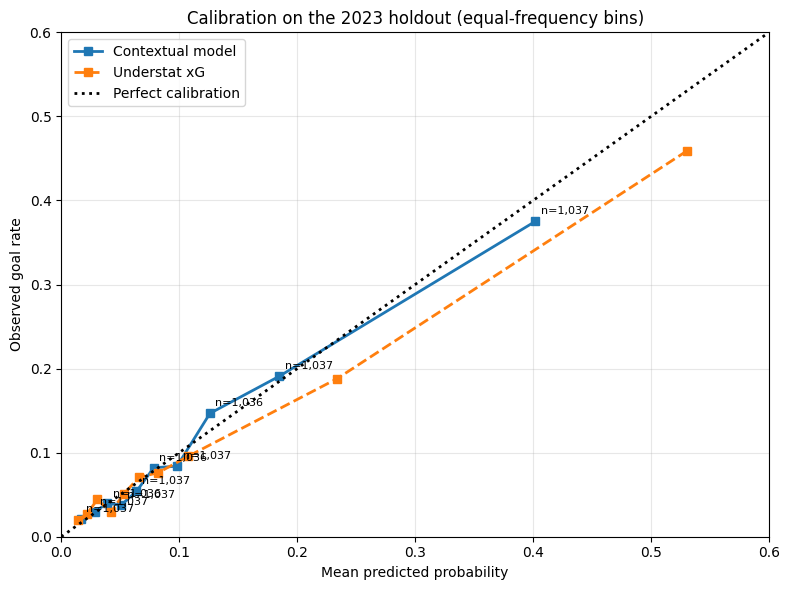

In [9]:
def calibration_points(y_true, probabilities, bins=10):
    observed, predicted = calibration_curve(
        y_true, probabilities, n_bins=bins, strategy="quantile"
    )
    bin_ids = pd.qcut(probabilities, q=bins, labels=False, duplicates="drop")
    counts = pd.Series(bin_ids).value_counts().sort_index().to_numpy()
    return observed, predicted, counts


observed_model, predicted_model, bin_counts = calibration_points(
    y_validation.to_numpy(), validation_predictions
)
observed_understat, predicted_understat, _ = calibration_points(
    y_validation.to_numpy(), understat_predictions
)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(predicted_model, observed_model, "s-", label="Contextual model", linewidth=2)
ax.plot(predicted_understat, observed_understat, "s--", label="Understat xG", linewidth=2)
ax.plot([0, 0.6], [0, 0.6], "k:", label="Perfect calibration", linewidth=2)
for x_value, y_value, count in zip(predicted_model, observed_model, bin_counts):
    ax.annotate(f"n={count:,}", (x_value, y_value), xytext=(4, 5), textcoords="offset points", fontsize=8)
ax.set(xlabel="Mean predicted probability", ylabel="Observed goal rate", xlim=(0, 0.6), ylim=(0, 0.6))
ax.set_title("Calibration on the 2023 holdout (equal-frequency bins)")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "calibration_plot.png", dpi=180, bbox_inches="tight")
plt.show()


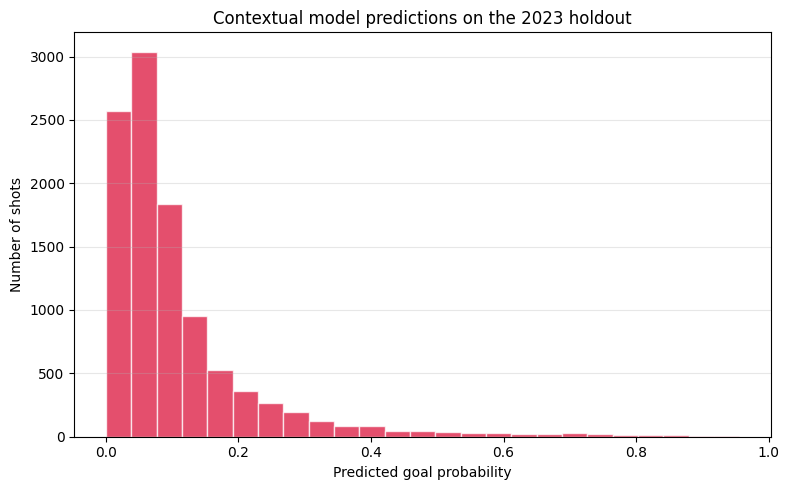

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(validation_predictions, bins=25, color="crimson", edgecolor="white", alpha=0.75)
ax.set_xlabel("Predicted goal probability")
ax.set_ylabel("Number of shots")
ax.set_title("Contextual model predictions on the 2023 holdout")
ax.grid(alpha=0.3, axis="y")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "prediction_histogram.png", dpi=180, bbox_inches="tight")
plt.show()


## Permutation Importance

Raw coefficients are hard to compare across encodings and correlated inputs. Permutation importance instead measures how much validation log loss worsens when one input is shuffled. It describes predictive reliance, not causation.

,feature,log_loss_increase,std
0,distance_meters,0.0369,0.0027
1,angle_radians,0.0343,0.0015
2,lastAction,0.0151,0.0013
3,follows_takeon,0.0056,0.0007
4,situation,0.0048,0.0005
5,follows_throughball,0.0048,0.0005
6,shotType,0.0032,0.0004
7,follows_cross,0.0020,0.0004
8,follows_rebound,0.0016,0.0005
9,follows_aerial,0.0002,0.0001


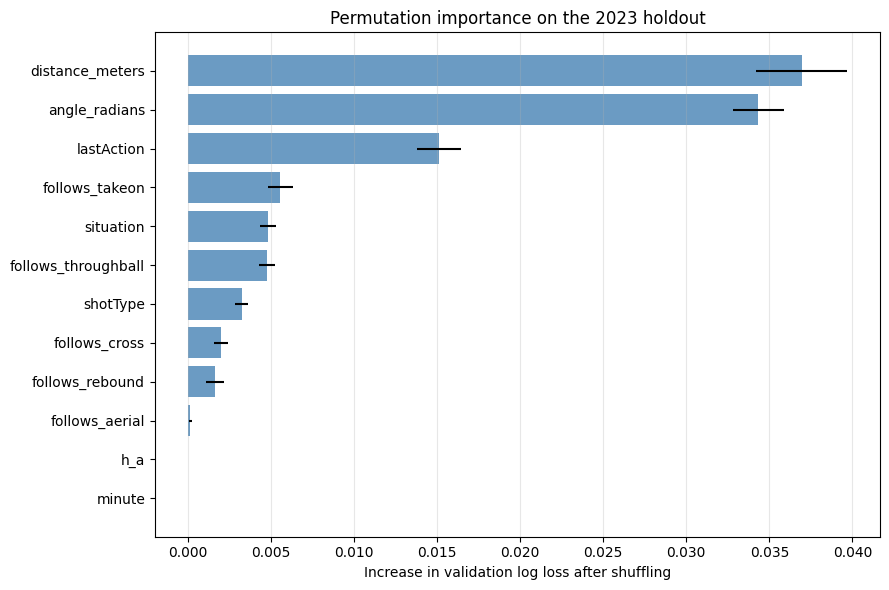

In [11]:
importance = permutation_importance(
    context_model,
    validation_data[context_features],
    y_validation,
    scoring="neg_log_loss",
    n_repeats=8,
    random_state=42,
    n_jobs=-1,
)
importance_df = pd.DataFrame({
    "feature": context_features,
    "log_loss_increase": importance.importances_mean,
    "std": importance.importances_std,
}).sort_values("log_loss_increase", ascending=False)
display(importance_df.reset_index(drop=True).round(4))

plot_data = importance_df.head(12).sort_values("log_loss_increase")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    plot_data["feature"], plot_data["log_loss_increase"],
    xerr=plot_data["std"], color="steelblue", alpha=0.8,
)
ax.set_xlabel("Increase in validation log loss after shuffling")
ax.set_title("Permutation importance on the 2023 holdout")
ax.grid(alpha=0.3, axis="x")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "feature_importance.png", dpi=180, bbox_inches="tight")
plt.show()


## Understat xG Comparison

Brier score and log-loss comparison between our model and Understat's own xG.

In [12]:
understat_xg = model_data.loc[y_validation.index, "xG"]

comparison = pd.Series({
    "brier_our_model": brier_score_loss(y_validation, validation_predictions),
    "brier_understat": brier_score_loss(y_validation, understat_xg),
    "log_loss_our_model": log_loss(y_validation, validation_predictions),
    "log_loss_understat": log_loss(y_validation, understat_xg),
    "roc_auc_our_model": roc_auc_score(y_validation, validation_predictions),
    "roc_auc_understat": roc_auc_score(y_validation, understat_xg),
})

display(comparison.to_frame("value"))


,value
brier_our_model,0.082564
brier_understat,0.077463
log_loss_our_model,0.288580
log_loss_understat,0.272220
roc_auc_our_model,0.771258
roc_auc_understat,0.795218
